###  Python Assignment-5 :EXPLORATORY DATA ANALYSIS ON A DATASET

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Data Cleaning and Preparation:

In [22]:
#Load datset
data = pd.read_csv(r'Data\Cardiotocographic.csv')
data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [23]:
data.shape

(2126, 14)

In [3]:
data.info() # dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [4]:
# checking missing values 
data.isnull().sum() 

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [5]:
#data.dropna()

In [6]:
data.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [24]:
# Filling the null values 
data['LB']= data['LB'].fillna(data['LB'].mean())
data['AC']= data['AC'].fillna(data['AC'].median())
data['DS']= data['DS'].fillna(data['DS'].mean())
data['DP']= data['DP'].fillna(data['DP'].mean())
data['MLTV']= data['MLTV'].fillna(data['MLTV'].median())
data['Width']= data['Width'].fillna(data['Width'].median())
data['Tendency']= data['Tendency'].fillna(data['Tendency'].mode())
data['NSP']= data['NSP'].fillna(data['NSP'].mode()[0])

In [9]:
data.isna().sum() 

LB           0
AC           0
FM           0
UC           0
DL           0
DS           0
DP           0
ASTV         0
MSTV         0
ALTV         0
MLTV         0
Width        0
Tendency    21
NSP          0
dtype: int64

In [10]:
# check datatypes
data.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

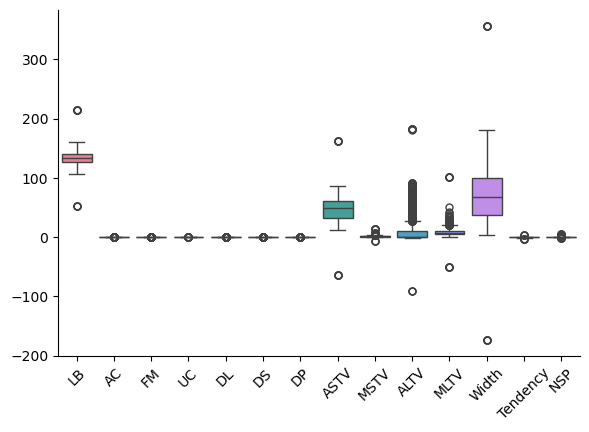

In [30]:
# Boxplot

sns.catplot(data,
           kind='box',
           height=4,
           aspect=1.5)
plt.xticks(rotation=45)
plt.show()

In [25]:
# deleting the outliers

cols = ['LB','ASTV','MSTV','MLTV','ALTV','Width']

data1 = data.copy()

for col in cols:
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data1 = data1[(data1[col] >= lower) & (data1[col] <= upper)]

In [26]:
data1.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
1,132.0,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.000000,0.0,1.0
2,133.0,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.000000,0.0,1.0
7,122.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,83.0,0.5,6.0,15.6,69.920261,1.0,3.0
8,122.0,0.038567,0.0,0.001517,0.000000,0.0,0.0,84.0,0.5,5.0,13.6,68.000000,1.0,3.0
9,122.0,0.000000,0.0,0.002967,0.000000,0.0,0.0,86.0,0.3,6.0,10.6,68.000000,1.0,3.0


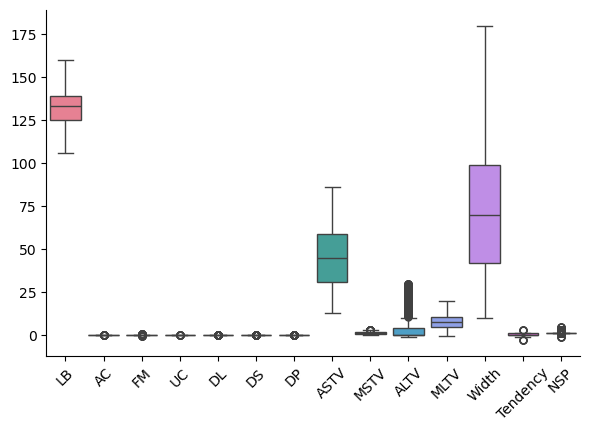

In [29]:
# Boxplot

sns.catplot(data1,
           kind='box',
           height=4,
           aspect=1.5)
plt.xticks(rotation=45)
plt.show()

### 2. Statistical Summary

In [31]:
data1.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1642.000000,1660.00000
mean,132.195214,0.003635,0.009292,0.004699,0.002014,0.000003,0.000196,45.067201,1.332829,3.692674,7.871716,72.796027,0.306283,1.22289
std,9.528068,0.004376,0.066489,0.003279,0.003283,0.000134,0.000817,16.116502,0.657908,6.975127,4.574570,35.426606,0.641236,0.58704
min,106.000000,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,13.000000,0.200000,-1.043619,-0.200788,10.000000,-3.000000,-1.00000
25%,125.000000,0.000000,0.000000,0.002571,0.000000,0.000000,0.000000,31.000000,0.800000,0.000000,4.800000,42.000000,0.000000,1.00000
50%,133.000000,0.002423,0.000000,0.004691,0.000000,0.000000,0.000000,45.000000,1.274529,0.000000,7.800000,70.000000,0.000000,1.00000
75%,139.000000,0.006151,0.002280,0.006766,0.003614,0.000000,0.000000,59.000000,1.700000,4.000000,10.800000,99.000000,1.000000,1.00000
max,160.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,86.000000,3.200000,30.000000,19.600000,180.000000,3.000000,5.00000


In [91]:
# Inter quantile range

cols = ['LB','ASTV','MSTV','MLTV','ALTV','Width']

data1 = data.copy()

for col in cols:
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f'{col}-IQR = {IQR}')

LB-IQR = 14.0
ASTV-IQR = 29.0
MSTV-IQR = 1.0
MLTV-IQR = 6.200000000000001
ALTV-IQR = 11.0
Width-IQR = 63.0


### 3. Data Visualization

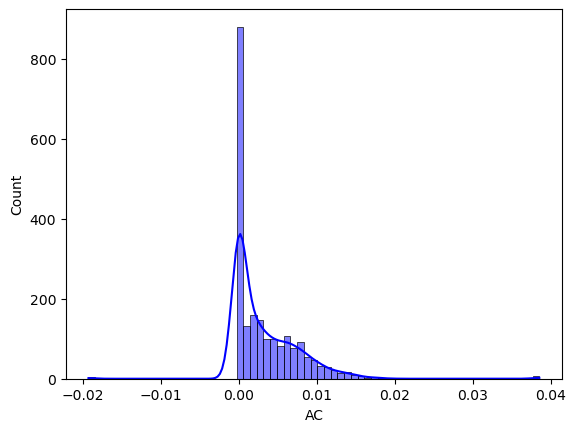

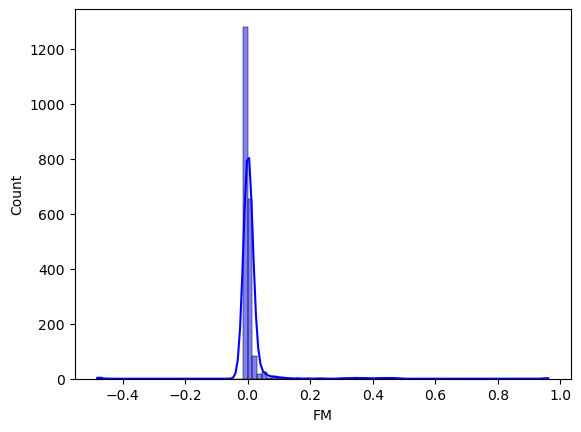

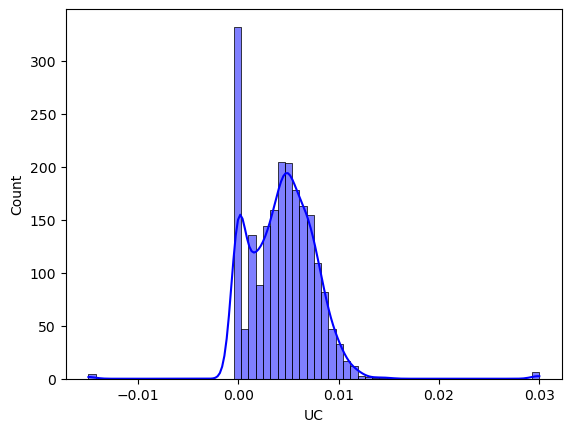

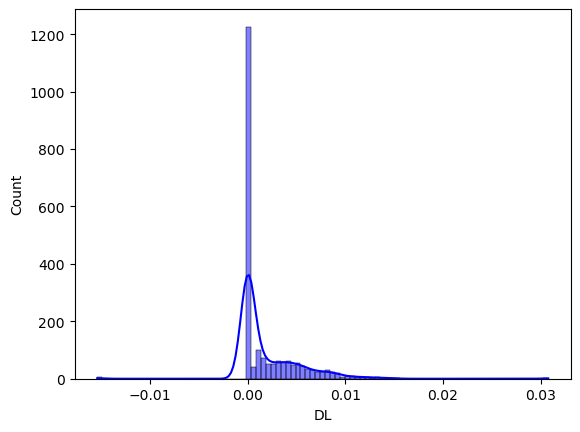

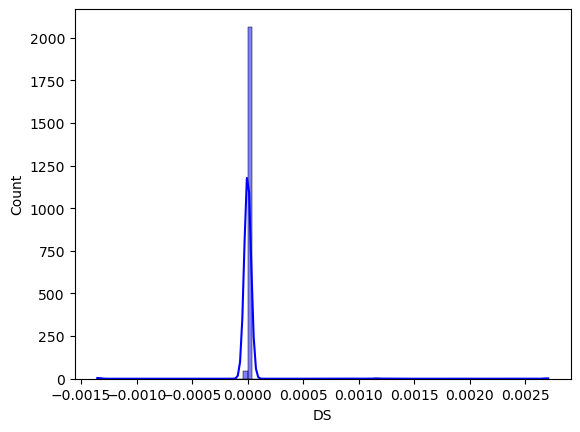

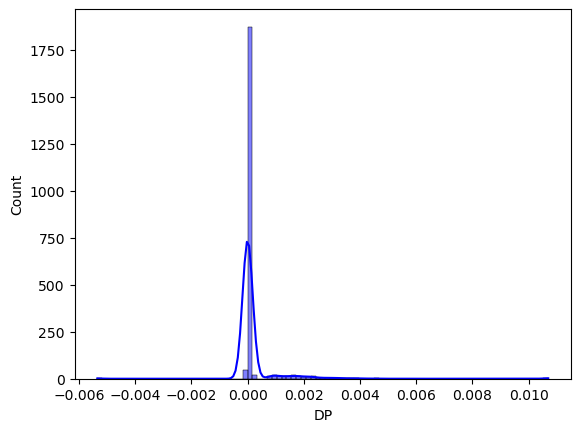

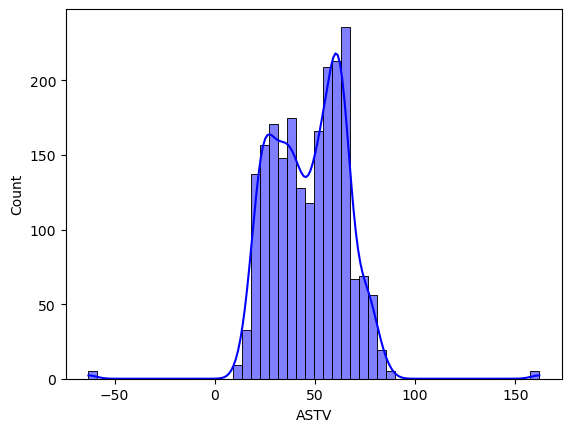

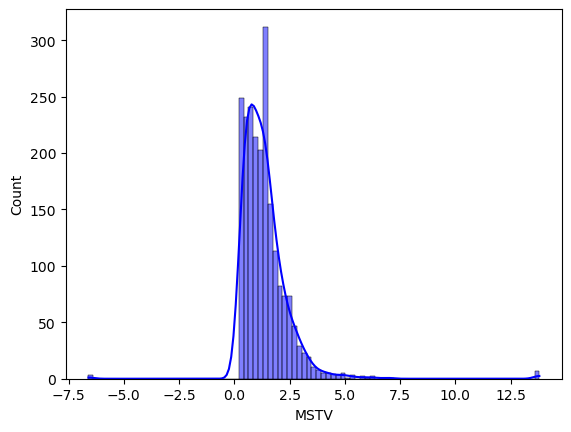

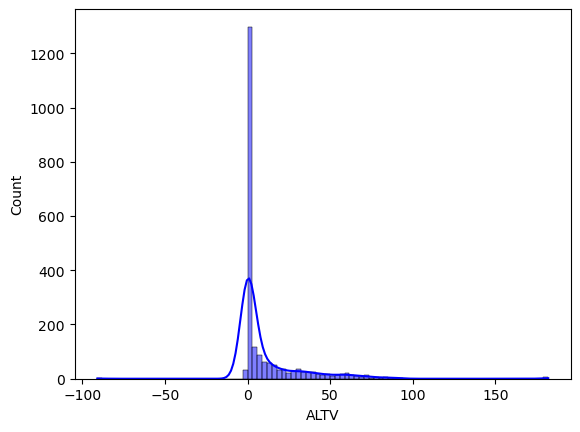

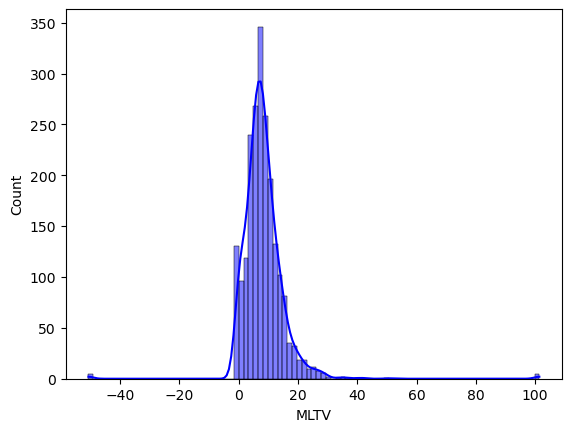

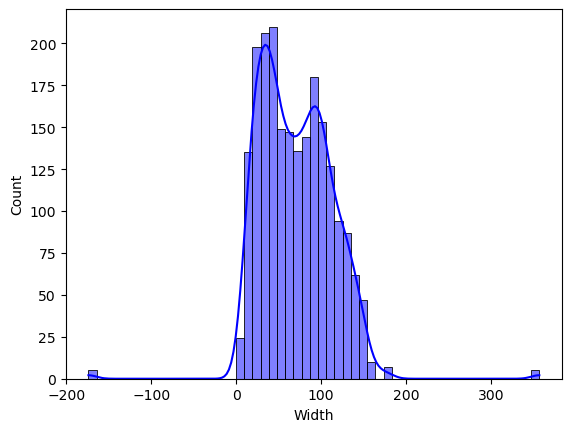

In [43]:
# histogram plot

cols=['AC','FM','UC','DL','DS','DP','ASTV','MSTV','ALTV','MLTV','Width']

for col in cols:
    sns.histplot(data1,
                 x=col,
                 kde=True,
                 color='Blue',
                 edgecolor='black'
                )
    plt.show()

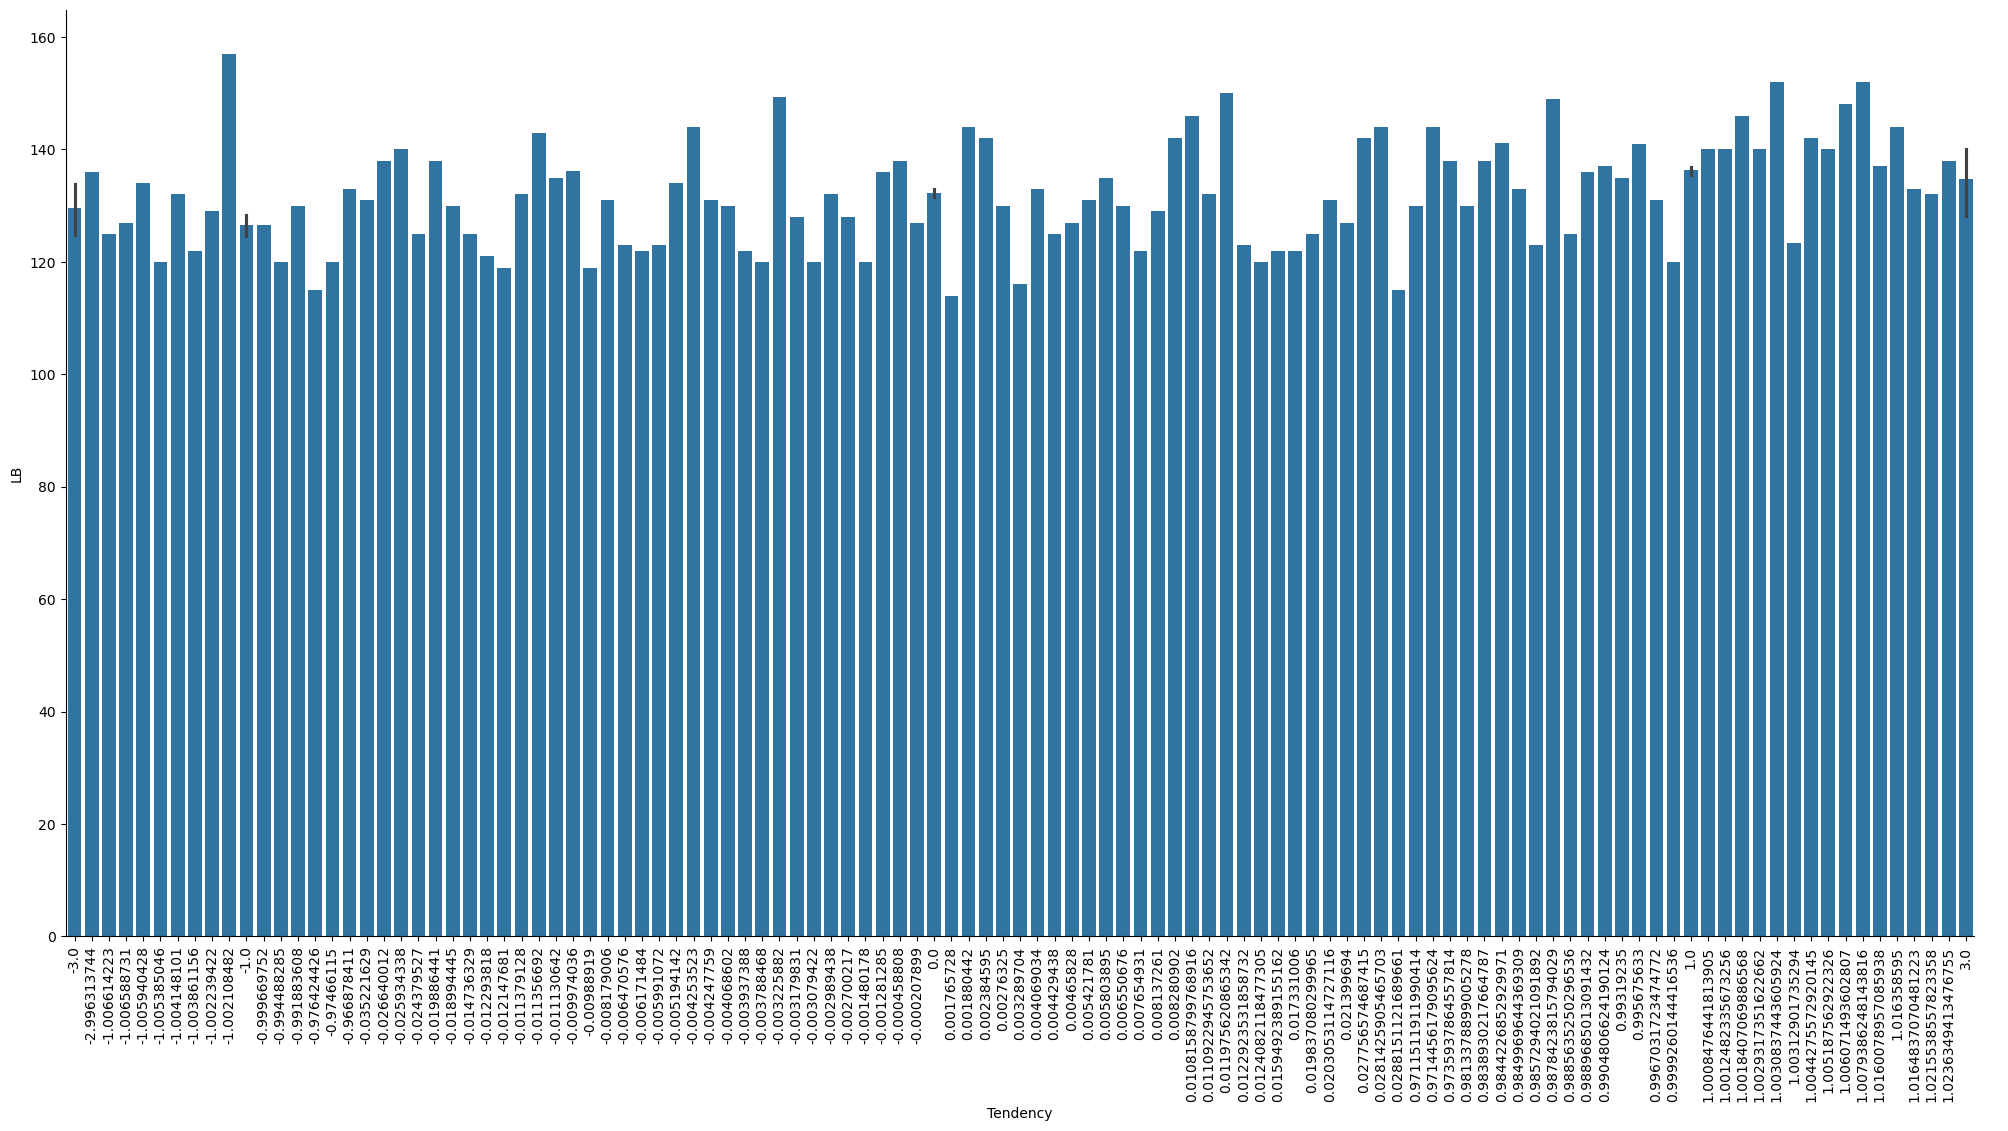

In [90]:
# Barplot

# plt.figure(figsize=(10,10))
sns.catplot(data1,x='Tendency',y='LB', kind='bar',height=10,aspect=2)
plt.xticks(rotation=90)
plt.show()

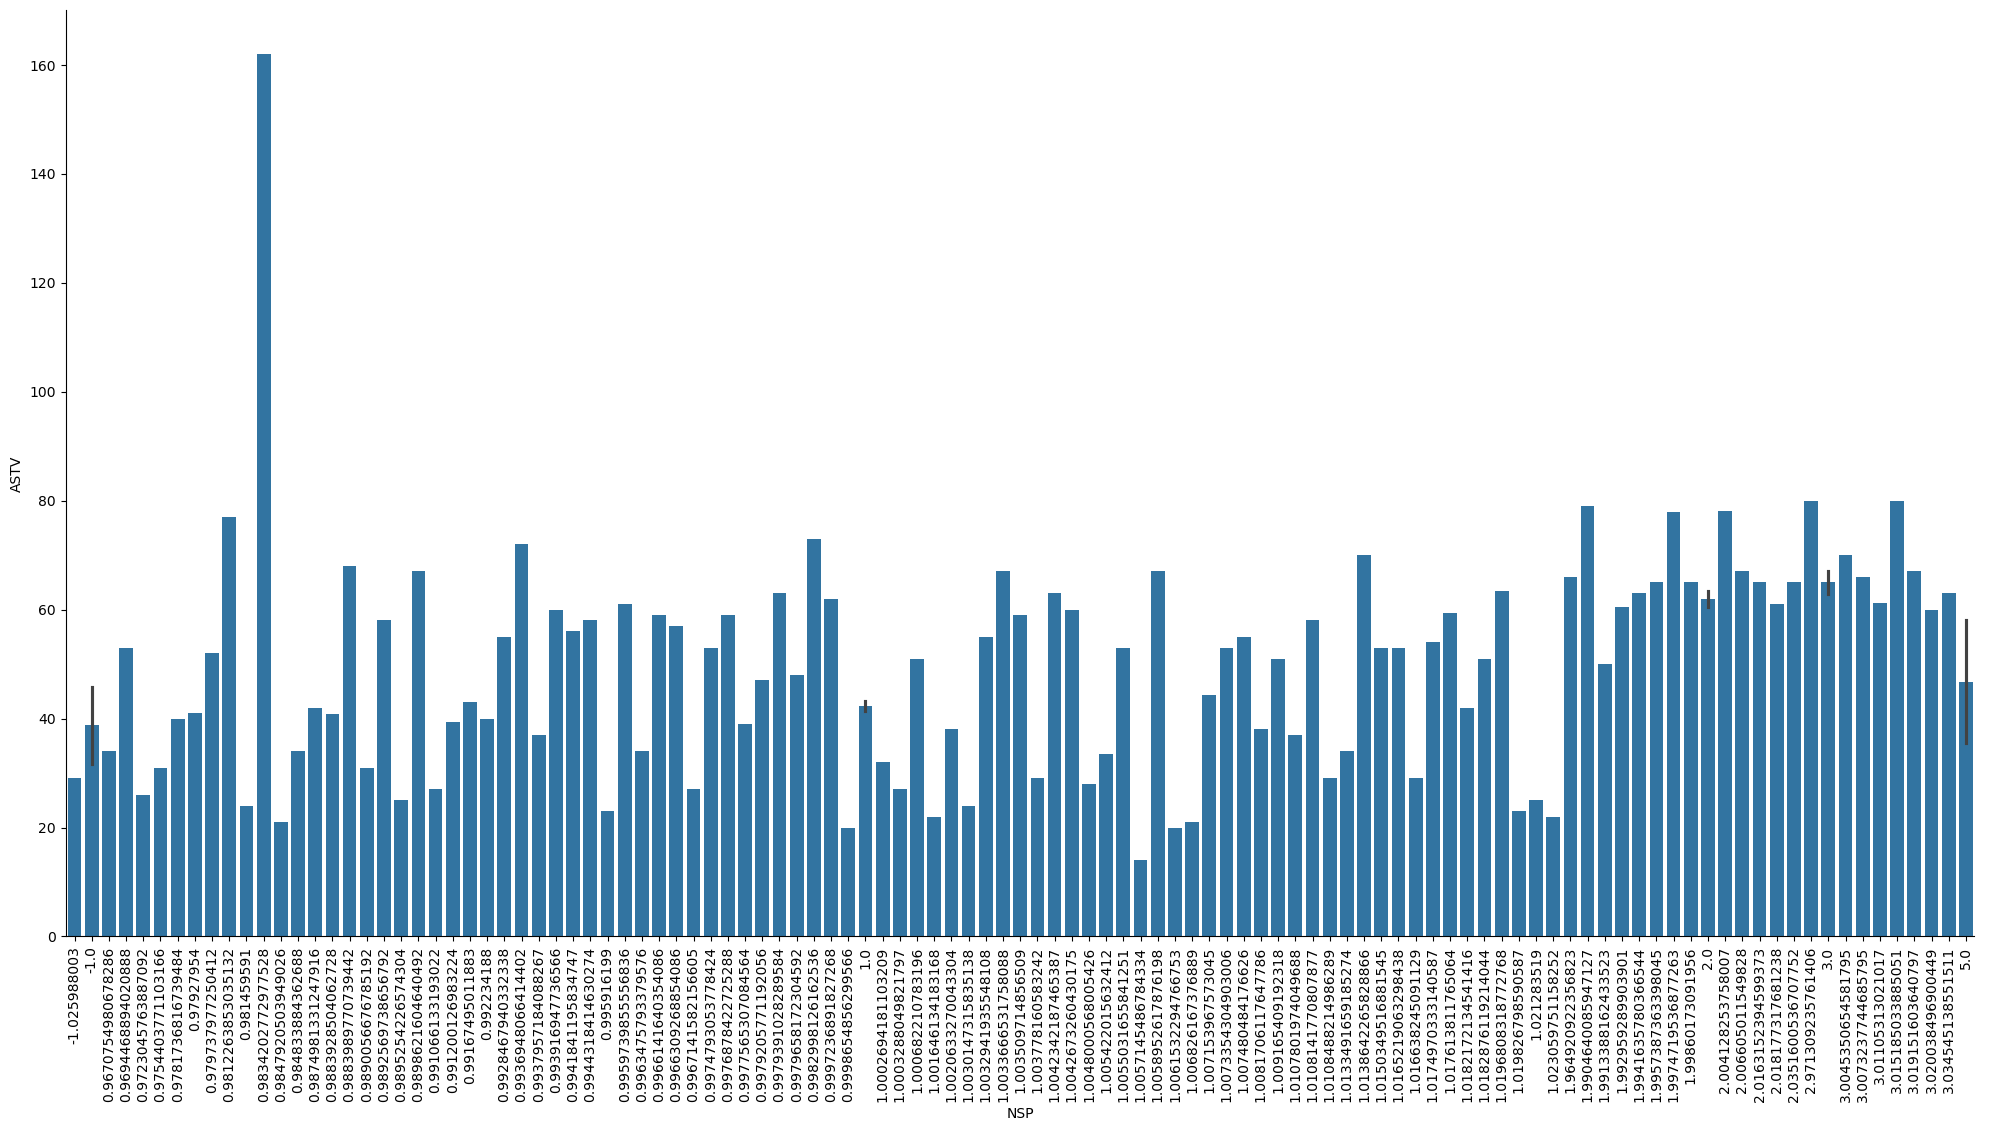

In [89]:
#Barplot

# plt.figure(figsize=(10,10))
sns.catplot(data1,x='NSP',y='ASTV', kind='bar',height=10,aspect=2)
plt.xticks(rotation=90)
plt.show()

In [58]:
corr = data1.corr()
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.062801,0.018776,-0.166201,-0.126536,-0.005438,-0.047724,0.241857,-0.169561,0.210446,-0.003457,-0.118421,0.236864,0.131698
AC,-0.062801,1.000000,0.009768,0.071621,-0.093449,-0.033081,-0.083226,-0.230470,0.132962,-0.269807,-0.104853,0.234549,0.032481,-0.311689
FM,0.018776,0.009768,1.000000,-0.053226,0.009718,0.029899,0.121274,-0.032691,0.017055,-0.011936,-0.006121,0.097282,-0.018339,0.074446
UC,-0.166201,0.071621,-0.053226,1.000000,0.190128,-0.006922,0.070501,-0.181161,0.189406,-0.227304,-0.049452,0.107083,-0.066610,-0.185229
DL,-0.126536,-0.093449,0.009718,0.190128,1.000000,0.058430,0.144940,-0.069361,0.410102,-0.186967,-0.165293,0.408578,-0.023569,0.024879
DS,-0.005438,-0.033081,0.029899,-0.006922,0.058430,1.000000,0.004285,0.008425,0.016077,-0.004392,0.034347,0.040831,-0.015398,0.065328
DP,-0.047724,-0.083226,0.121274,0.070501,0.144940,0.004285,1.000000,0.038117,0.119250,-0.077654,-0.114077,0.175335,-0.130395,0.294148
ASTV,0.241857,-0.230470,-0.032691,-0.181161,-0.069361,0.008425,0.038117,1.000000,-0.293882,0.357497,-0.219709,-0.206931,-0.010927,0.420873
MSTV,-0.169561,0.132962,0.017055,0.189406,0.410102,0.016077,0.119250,-0.293882,1.000000,-0.291935,0.028452,0.432822,-0.036857,-0.095876
ALTV,0.210446,-0.269807,-0.011936,-0.227304,-0.186967,-0.004392,-0.077654,0.357497,-0.291935,1.000000,-0.107200,-0.345732,0.036771,0.366454


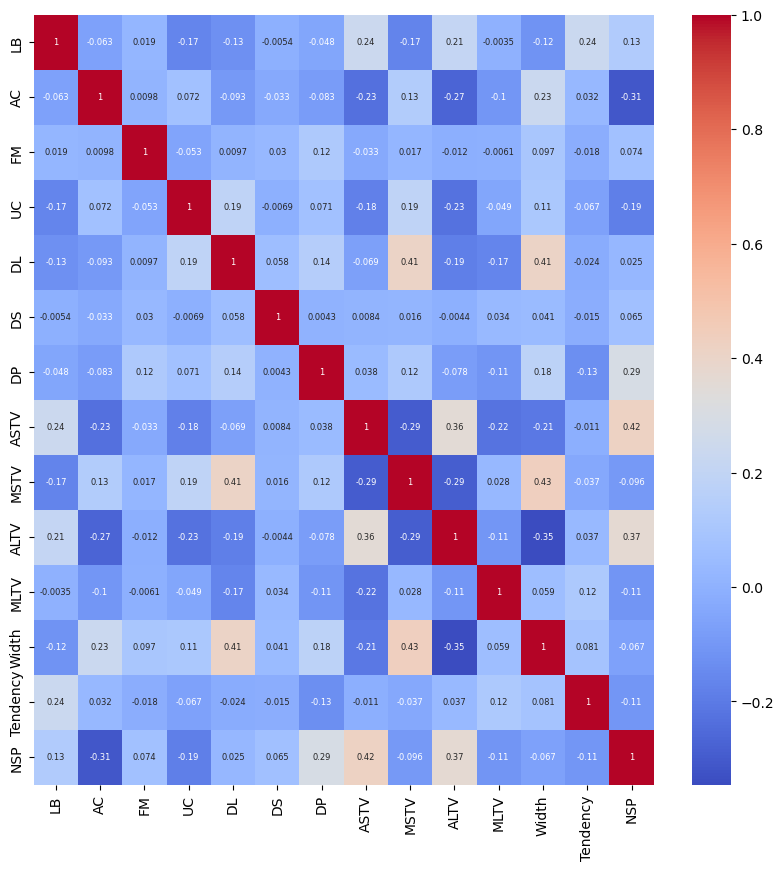

In [82]:
# HeatMap

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, annot_kws={'size':6}, cmap='coolwarm')
plt.show()

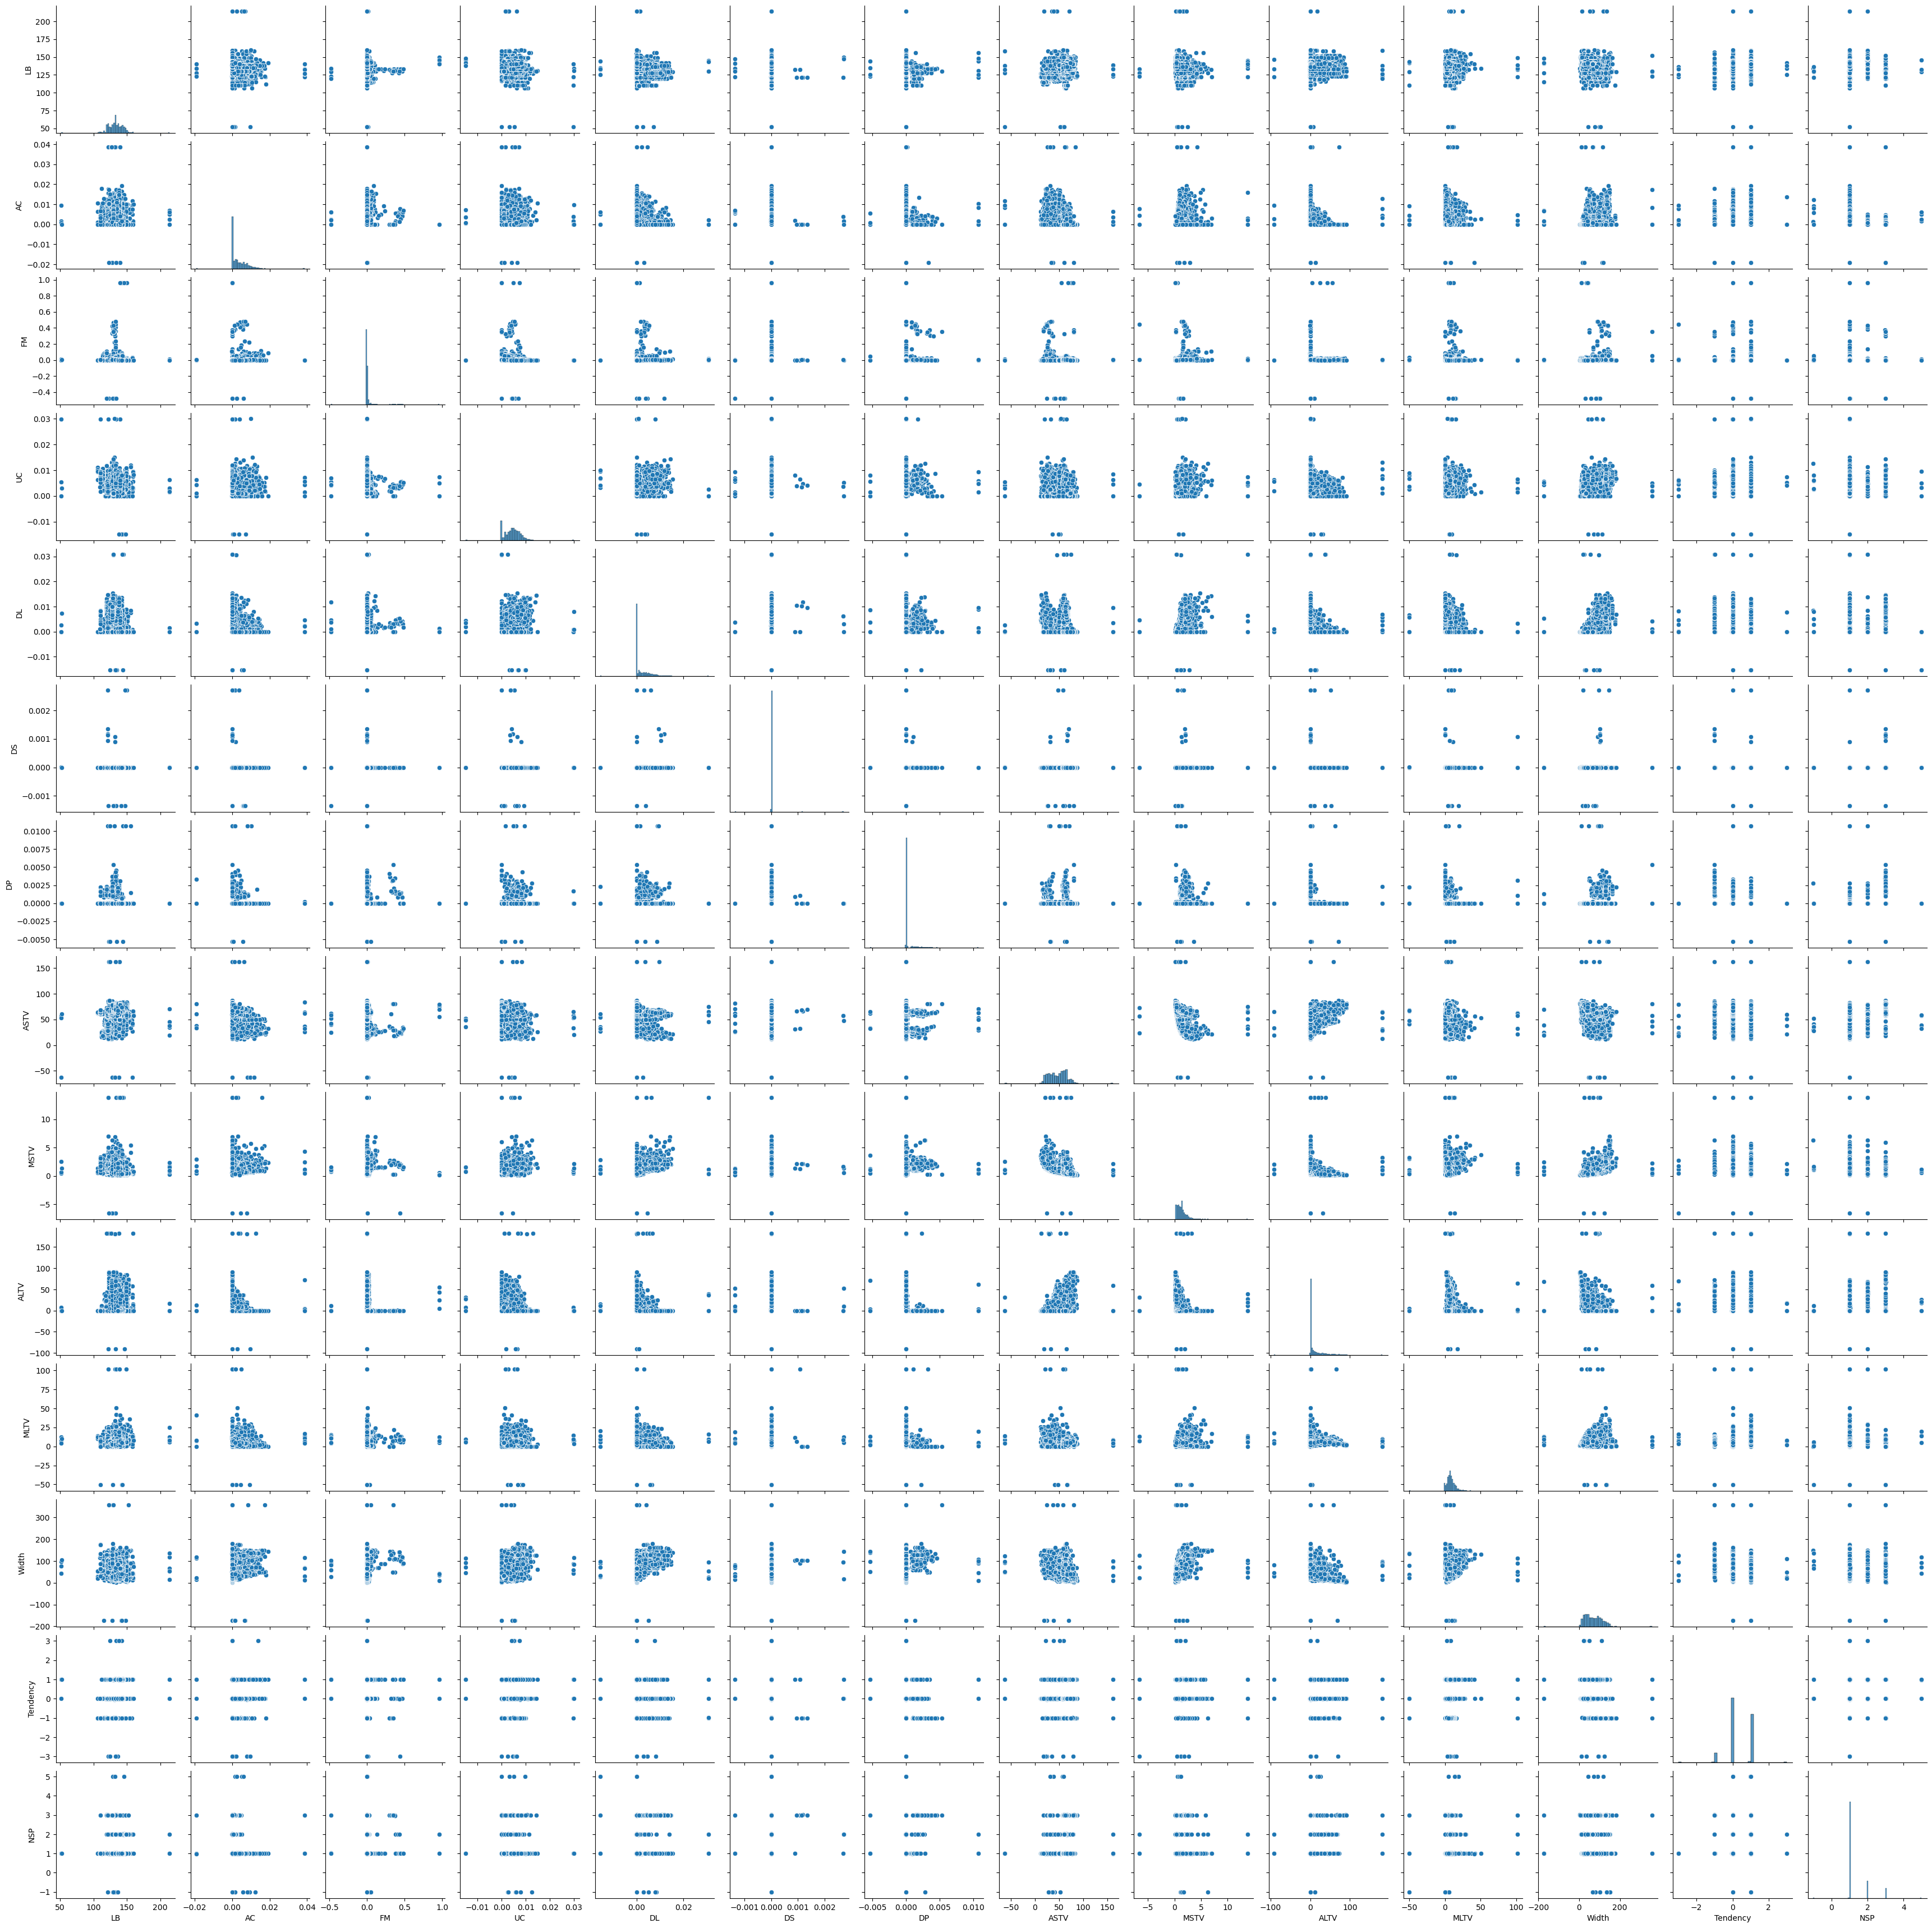

In [81]:
# Pairplot

sns.pairplot(data1)
plt.show()

### 4. Pattern Recognition and Insights:

In [ ]:
*Trends Over Time

-> The dataset does not contain a temporal or time-based column, so trend analysis over time cannot be performed.

-> However, if time-series data were available, we could analyze:

1. Changes in fetal heart rate over time

2. Variations in heart rate variability patterns.

### 5. Conclusion